<a href="https://colab.research.google.com/github/jrsales2024/FRAUDES/blob/main/fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **PROBLEMA DE CLASSIFICAÇÃO DESBALANCEADA**

Fraudes são raras - modelo pode ignorar a classe 1

In [4]:
df ["Class"].value_counts(normalize=True)


,proportion
Class,
0,0.998273
1,0.001727


Feature Engineering

Criamos variaveis que ajudam o modelo

In [11]:
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

### **Re-preparação de Dados para Treinamento de Modelo (após Feature Engineering)**

A feature engineering foi aplicada ao DataFrame principal (`df`). Para garantir que os conjuntos de treino e teste (`X_train`, `X_test`) e o conjunto de treino reamostrado (`X_train_res`) contenham consistentemente as novas features (`Amount_log`, `Amount_scaled`) e evitar inconsistências, precisamos redefinir `X` e `y`, e então refazer a divisão de treino/teste e a aplicação do SMOTE.

Para otimizar o modelo e evitar multicolinearidade, removeremos a coluna original `Amount`, utilizando apenas suas versões logarítmica e escalada.

In [27]:
# Separar features (X) e target (y) após feature engineering
# Removendo 'Amount' para usar 'Amount_log' e 'Amount_scaled'
X = df.drop(['Class', 'Amount'], axis=1)
y = df['Class']

print(f"Shape de X (atualizado): {X.shape}")
print(f"Shape de y (atualizado): {y.shape}")

Shape de X (atualizado): (284807, 30)
Shape de y (atualizado): (284807,)


### **Re-divisão dos Dados em Treino e Teste**

Agora, com o conjunto de features `X` atualizado, vamos dividir os dados novamente.

In [28]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Proporção da classe 0 no treino (atualizado): {y_train.value_counts(normalize=True)[0]:.4f}")
print(f"Proporção da classe 1 no treino (atualizado): {y_train.value_counts(normalize=True)[1]:.4f}")
print(f"Proporção da classe 0 no teste (atualizado): {y_test.value_counts(normalize=True)[0]:.4f}")
print(f"Proporção da classe 1 no teste (atualizado): {y_test.value_counts(normalize=True)[1]:.4f}")

Proporção da classe 0 no treino (atualizado): 0.9983
Proporção da classe 1 no treino (atualizado): 0.0017
Proporção da classe 0 no teste (atualizado): 0.9983
Proporção da classe 1 no teste (atualizado): 0.0017


### **Re-aplicação do Tratamento de Desbalanceamento com SMOTE**

Com os novos conjuntos de treino, aplicaremos o SMOTE novamente para balancear as classes.

In [29]:
# Aplicar SMOTE no conjunto de treino atualizado
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Contagem de classes após SMOTE no treino (atualizado):")
display(y_train_res.value_counts())

Contagem de classes após SMOTE no treino (atualizado):


,count
Class,
0,227451
1,227451


### **Treinamento e Avaliação de um Modelo Random Forest (Re-execução)**

Agora que os dados de treino e teste estão consistentes e balanceados, vamos treinar e avaliar o modelo Random Forest novamente.

In [30]:
# Importar RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Treinar um modelo Random Forest com os dados reamostrados e atualizados
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

# Fazer previsões no conjunto de teste com Random Forest
y_pred_rf = rf_model.predict(X_test)

# Avaliar o modelo Random Forest
print("\nClassification Report (Random Forest - Atualizado):")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix (Random Forest - Atualizado):")
display(confusion_matrix(y_test, y_pred_rf))


Classification Report (Random Forest - Atualizado):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix (Random Forest - Atualizado):


array([[56848,    16],
       [   17,    81]])

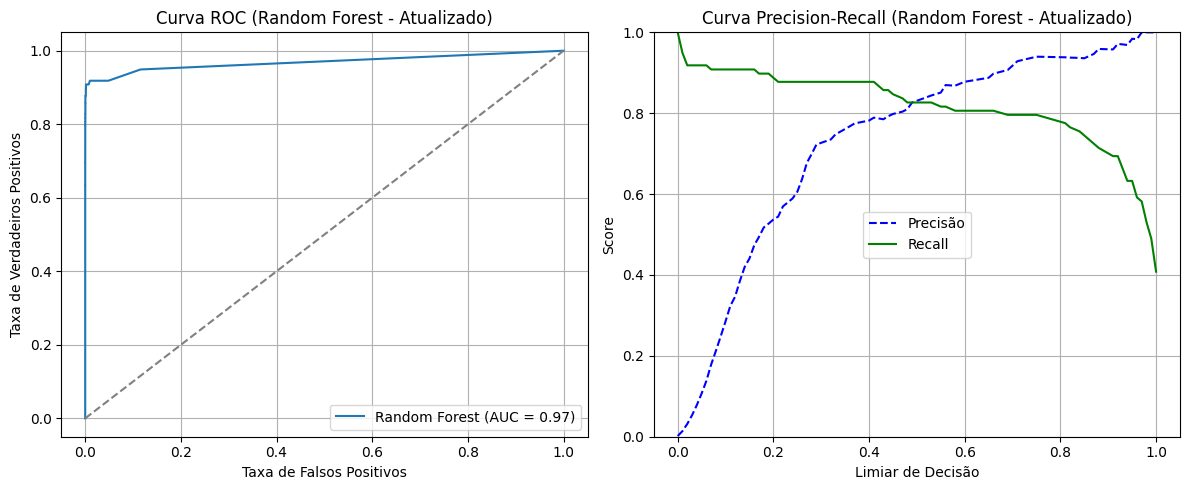

AUC (Random Forest - Atualizado): 0.9688642180986069


In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# Gerar probabilidades para a Curva ROC e Precision-Recall
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_probs_rf):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC (Random Forest - Atualizado)')
plt.legend()
plt.grid(True)

# Curva Precision-Recall
precisions_rf, recalls_rf, thresholds_pr_rf = precision_recall_curve(y_test, y_probs_rf)

plt.subplot(1, 2, 2)
plt.plot(thresholds_pr_rf, precisions_rf[:-1], "b--", label="Precisão")
plt.plot(thresholds_pr_rf, recalls_rf[:-1], "g-", label="Recall")
plt.xlabel("Limiar de Decisão")
plt.ylabel("Score")
plt.title('Curva Precision-Recall (Random Forest - Atualizado)')
plt.legend(loc="center")
plt.ylim([0, 1])
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"AUC (Random Forest - Atualizado): {roc_auc_score(y_test, y_probs_rf)}")

LOGISTIC REGRESSION

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
display(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.53      0.63       148

    accuracy                           1.00     85443
   macro avg       0.89      0.76      0.82     85443
weighted avg       1.00      1.00      1.00     85443


Confusion Matrix:


array([[85274,    21],
       [   70,    78]])

### **Preparação de Dados para Treinamento de Modelo**

Dado que o problema é de classificação desbalanceada, vamos preparar os dados de forma a lidar com isso antes de treinar um modelo.

In [5]:
# Importar bibliotecas necessárias
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

### **Definição de Features (X) e Target (y)**

Vamos separar as features (variáveis independentes) da variável alvo (Class).

In [6]:
# Separar features (X) e target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (284807, 30)
Shape de y: (284807,)


### **Divisão dos Dados em Treino e Teste**

É crucial dividir os dados para treinar o modelo em uma parte e testá-lo em outra, garantindo que o modelo generalize bem para dados não vistos.

In [7]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Proporção da classe 0 no treino: {y_train.value_counts(normalize=True)[0]:.4f}")
print(f"Proporção da classe 1 no treino: {y_train.value_counts(normalize=True)[1]:.4f}")
print(f"Proporção da classe 0 no teste: {y_test.value_counts(normalize=True)[0]:.4f}")
print(f"Proporção da classe 1 no teste: {y_test.value_counts(normalize=True)[1]:.4f}")

Proporção da classe 0 no treino: 0.9983
Proporção da classe 1 no treino: 0.0017
Proporção da classe 0 no teste: 0.9983
Proporção da classe 1 no teste: 0.0017


### **Tratamento de Desbalanceamento com SMOTE**

Para lidar com o desbalanceamento da classe, usaremos SMOTE (Synthetic Minority Over-sampling Technique) para gerar amostras sintéticas da classe minoritária no conjunto de treino.

In [25]:
# Aplicar SMOTE apenas no conjunto de treino com o X_train atualizado
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Contagem de classes após SMOTE no treino:")
display(y_train_res.value_counts())

Contagem de classes após SMOTE no treino:


,count
Class,
0,199020
1,199020


### **Treinamento de um Modelo de Regressão Logística**

Agora que o conjunto de treino está balanceado, podemos treinar um modelo de Regressão Logística, que é um bom ponto de partida para problemas de classificação binária.

In [9]:
# Treinar um modelo de Regressão Logística
model = LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1, max_iter=1000)
model.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42,
                   solver='liblinear')

### **Avaliação do Modelo**

Vamos avaliar o desempenho do modelo no conjunto de teste (não visto durante o treinamento) usando o `classification_report` e a `confusion_matrix`.

In [10]:
# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
display(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:


array([[55739,  1125],
       [    9,    89]])

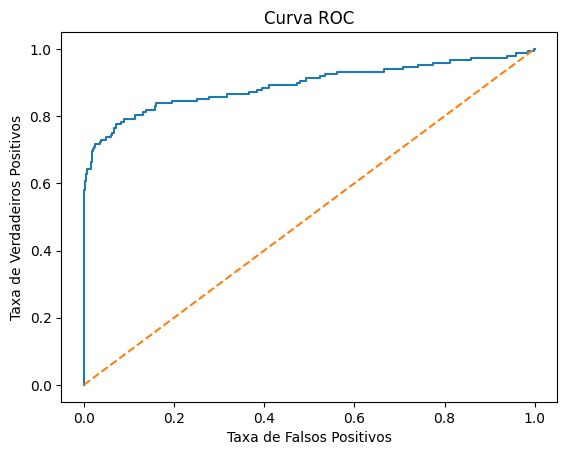

AUC: 0.8916914745802722


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.show()

print ("AUC:" ,  roc_auc_score(y_test, y_probs))


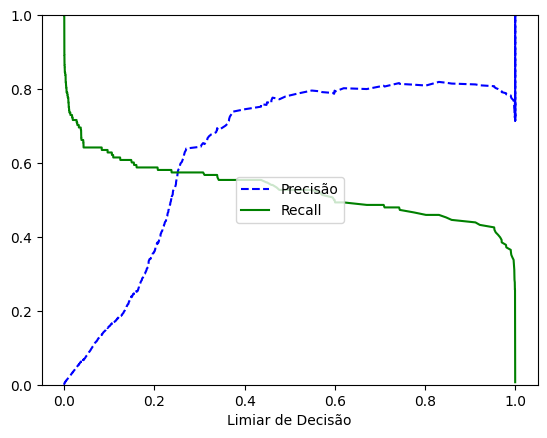

In [21]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(thresholds, precisions[:-1], "b--", label="Precisão")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Limiar de Decisão")
plt.legend(loc="center")
plt.ylim([0, 1])
plt.show()

### **Treinamento e Avaliação de um Modelo Random Forest**

Agora vamos treinar e avaliar um modelo Random Forest para comparar seu desempenho com a Regressão Logística.

In [22]:
# Importar RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Treinar um modelo Random Forest
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(n_jobs=-1, random_state=42)